# Sprint 7 — HPO Random vs Bayesian para política criticidad Var2 (UNI)

**Entregable semana:** experimentos comparables Random/Bayes con pruning, logs/artefactos, tabla top-k, gráfico de evolución y resumen espacio/presupuesto/decisión.

**Continuidad:** extiende [`sprint6_metagpt_multiagente_uni_n40`](sprint6_metagpt_multiagente_uni_n40.ipynb) (MetaGPT Team, n=40, BugsRepo, play/pausa/stop). Aquí **no se re-llama el LLM**: se optimiza la **política de criticidad post-RAG** sobre predicciones/cache del sprint 6.

**Protocolo:** seed=42, calibración HPO solo en split train (n=600), evaluación final en test n=40 idéntico al sprint 6.


## Fase 1 — Análisis exploratorio (pasada 1)

### Hiperparámetros calibrados manualmente en Sprint 6 (Var2)

En `calibrate_policy()` del sprint 6 se exploró una **rejilla manual** sobre el split de calibración (n=600):

| Parámetro | Rango / valores manuales | Notas |
|-----------|--------------------------|-------|
| `weights` | 3 plantillas fijas (base/risk/p_stop/uncertainty/rag_gap/fuzzy_stop) | Suma ≈ 1.0 |
| `threshold_stop` | 0.50–0.76 (paso 0.04) | Umbral score → STOP |
| `threshold_pausa` | 0.24–0.58 (< threshold_stop) | Umbral score → PAUSA |
| `risk_stop_floor` | {0.20, 0.28, 0.36, 0.44} | Piso riesgo 4D para regla costo |
| `p_stop_floor` | {0.40, 0.50, 0.60} | Piso probabilidad STOP |
| `stop_cost_threshold` | 0.38 (`stop_heavy`) / 0.48 (`balanced`) | Costo esperado FN-STOP vs HITL |
| `pause_uncertainty` | 0.48 (fijo) | Incertidumbre para play→pausa |
| `mode` | `balanced` vs `stop_heavy` | Objetivo: F1-macro + α·F1-STOP − β·PolicyCost |

**Decisión sprint 6:** se eligió `stop_heavy` porque Var2 `balanced` no superaba comparadores en test; la config ganadora manual fue la fila top de `calibration_grid_stop_heavy.csv` (F1-Macro test=0.6072, PolicyCost=0.119).

### Referencias web (HPO, pruning, cost-sensitive / SE)

1. **Bergstra & Bengio (2012)** — *Random Search for Hyper-Parameter Optimization*, JMLR 13:281–305. Demuestra que muestreo aleatorio supera grid search cuando pocas dimensiones importan. [PDF JMLR](https://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.pdf) · [página JMLR](https://jmlr.org/papers/v13/bergstra12a.html)

2. **Snoek, Larochelle & Adams (2012)** — *Practical Bayesian Optimization of Machine Learning Algorithms*, NeurIPS 2012. Modela desempeño con GP y propone optimización secuencial (base de Spearmint). [NeurIPS](https://papers.nips.cc/paper/4522-practical-bayesian-optimization-of-machine-learning-algorithms) · [arXiv:1206.2944](https://arxiv.org/abs/1206.2944)

3. **Optuna — TPESampler** (Tree-structured Parzen Estimator, sampler Bayesiano por defecto en optimización mono-objetivo). [OptunaHub 3.6.1](https://hub.optuna.org/optuna_versions/3.6.1/)

4. **Optuna — MedianPruner** (early stopping: poda si el trial está por debajo de la mediana en el mismo step). [documentación MedianPruner](https://optuna.readthedocs.io/en/latest/reference/generated/optuna.pruners.MedianPruner.html) · [módulo pruners](https://optuna.readthedocs.io/en/stable/reference/pruners.html)

5. **Li et al. (2018)** — *Massively Parallel Hyperparameter Tuning* (ASHA / Successive Halving asíncrono). Early stopping agresivo para HPO paralelo. [arXiv:1810.05934](https://arxiv.org/abs/1810.05934) · [blog ML@CMU](https://blog.ml.cmu.edu/2018/12/12/massively-parallel-hyperparameter-optimization/)

6. **Park et al. (2011)** — *CosTriage: A Cost-Aware Triage Algorithm for Bug Reporting Systems*, AAAI. Optimiza accuracy **y costo** en triage de bugs (análogo a PolicyCost HITL). [ML Anthology](https://mlanthology.org/aaai/2011/park2011aaai-costriage/)


## Fase 2 — Análisis crítico (pasada 2)

### ¿Qué optimizar SIN re-llamar LLM?

| Optimizable (esta semana) | NO optimizable sin LLM |
|-------------------------|------------------------|
| Pesos `weights` del score combinado | Prompts/roles MetaGPT Team |
| Umbrales `threshold_stop/pausa` | Temperatura/modelo DeepSeek |
| Pisos `risk_stop_floor`, `p_stop_floor` | top-k pgvector (fijo k=5) |
| `stop_cost_threshold`, `pause_uncertainty` | Predicciones Var1 cacheadas |
| Modo objetivo `stop_heavy` / `balanced` | Embeddings TF-IDF+SVD |

**Honestidad metodológica:** este HPO **no re-optimiza MetaGPT ni el LLM**. Re-calibra la capa **criticidad Camino B-lite** que transforma features (RAG + riesgo 4D + incertidumbre) en play/pausa/stop, usando las mismas predicciones Var1 del sprint 6.

### Diseño experimental Sprint 7

- **Random Search** y **Bayesian (Optuna TPE)** con **mismo presupuesto** (`n_trials=80` cada uno).
- **Pruning:** `MedianPruner` con 5-fold CV estratificado en calibración como steps intermedios (early stopping por fold).
- **Objetivo primario (alineado tesis):** `objective()` compuesto = F1-macro + α·F1-STOP − β·PolicyCost (no solo accuracy).
- **Evaluación final:** config ganadora en test n=40 vs Var2 baseline sprint 6.


## Setup y rutas


In [1]:

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd().resolve()
for candidate in (ROOT, ROOT / 'tesis2', ROOT.parent / 'tesis2', ROOT.parent):
    marker = candidate / 'src' / 'sprint6_hpo_criticidad_random_bayes.py'
    if marker.exists():
        ROOT = candidate
        break

SPRINT6_DIR = ROOT / 'docs' / 'experiments' / 'sprint6_metagpt_multiagente_uni_n40'
OUT_DIR = ROOT / 'docs' / 'experiments' / 'sprint7_hpo_random_bayes_criticidad_uni_n40'
SCRIPT = ROOT / 'src' / 'sprint6_hpo_criticidad_random_bayes.py'
print('ROOT =', ROOT)
print('SPRINT6_DIR =', SPRINT6_DIR)
print('OUT_DIR =', OUT_DIR)



ROOT = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2
SPRINT6_DIR = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/docs/experiments/sprint6_metagpt_multiagente_uni_n40
OUT_DIR = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/docs/experiments/sprint7_hpo_random_bayes_criticidad_uni_n40


## Ejecutar HPO (script reproducible)


In [2]:

import subprocess, sys
py = ROOT / 'external' / 'criticidad_sota_env' / 'bin' / 'python'
if not py.exists():
    py = sys.executable
cmd = [str(py), str(SCRIPT), '--n-trials', '80', '--seed', '42']
print(' '.join(cmd))
# Idempotente: re-ejecuta si se desea refrescar artefactos
if not (OUT_DIR / 'summary.json').exists():
    subprocess.run(cmd, check=True, cwd=ROOT)
else:
    print('Artefactos ya presentes; omitiendo re-ejecución.')



/home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/external/criticidad_sota_env/bin/python /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/src/sprint6_hpo_criticidad_random_bayes.py --n-trials 80 --seed 42
Artefactos ya presentes; omitiendo re-ejecución.


## Tablas top-k (Random y Bayes)


In [3]:

top_random = pd.read_csv(OUT_DIR / 'top_k_random.csv')
top_bayes = pd.read_csv(OUT_DIR / 'top_k_bayes.csv')
display(Markdown('### Top-3 Random Search'))
display(top_random.head(3))
display(Markdown('### Top-3 Bayesian TPE'))
display(top_bayes.head(3))



### Top-3 Random Search

,rank,trial,objective_cv,test_f1_macro,test_f1_stop,test_accuracy,test_policy_cost,params_json
0,1,2,0.756509,0.7012,0.8148,0.725,0.129,"{""mode"": ""stop_heavy"", ""p_stop_floor"": 0.48, ""..."
1,2,22,0.746574,0.5908,0.8148,0.650,0.121,"{""mode"": ""stop_heavy"", ""p_stop_floor"": 0.44, ""..."
2,3,65,0.723519,0.5585,0.8148,0.650,0.115,"{""mode"": ""stop_heavy"", ""p_stop_floor"": 0.48, ""..."


### Top-3 Bayesian TPE

,rank,trial,objective_cv,test_f1_macro,test_f1_stop,test_accuracy,test_policy_cost,params_json
0,1,44,0.775987,0.7634,0.8148,0.775,0.133,"{""mode"": ""stop_heavy"", ""p_stop_floor"": 0.6, ""p..."
1,2,61,0.775987,0.7634,0.8148,0.775,0.133,"{""mode"": ""stop_heavy"", ""p_stop_floor"": 0.56, ""..."
2,3,72,0.775987,0.7634,0.8148,0.775,0.133,"{""mode"": ""stop_heavy"", ""p_stop_floor"": 0.56, ""..."


## Gráficos de evolución (best-so-far)


**evolution_best_so_far.png**

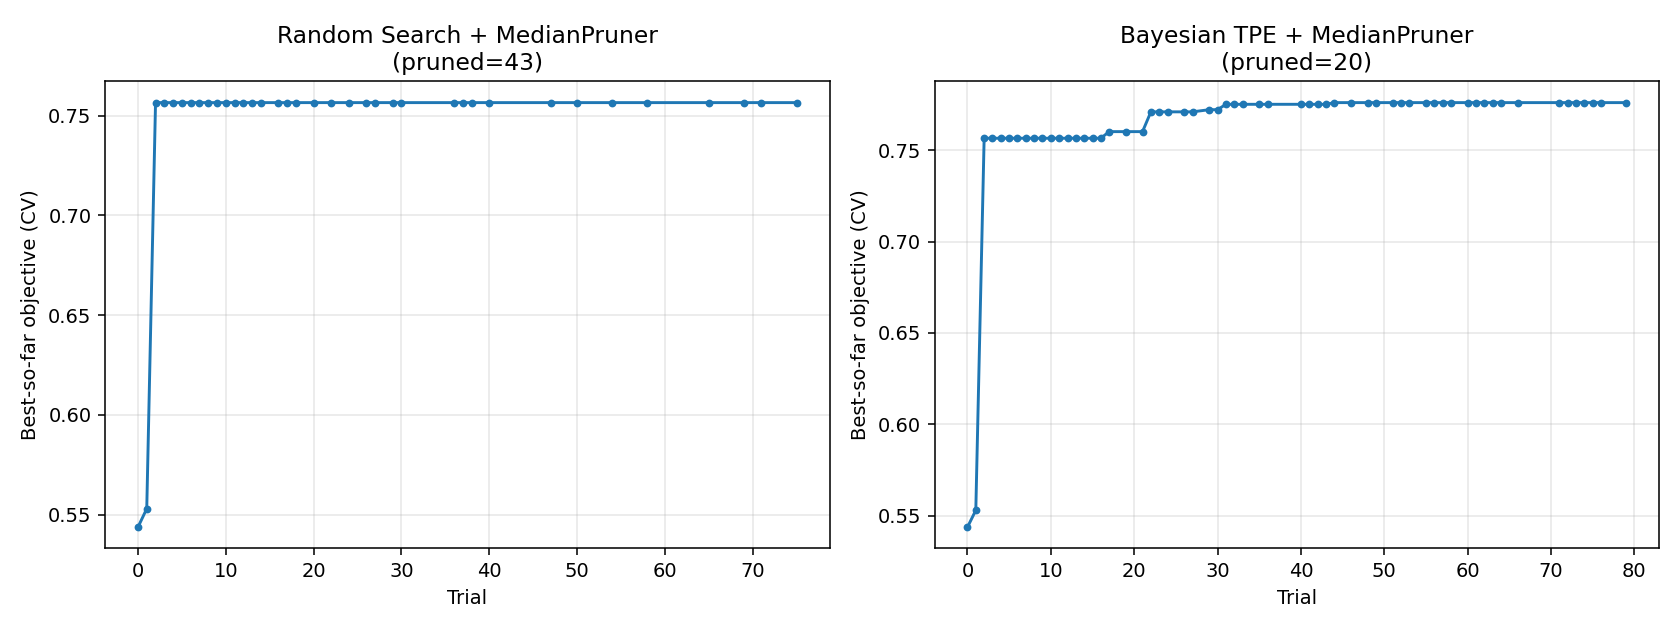

**comparison_random_vs_bayes.png**

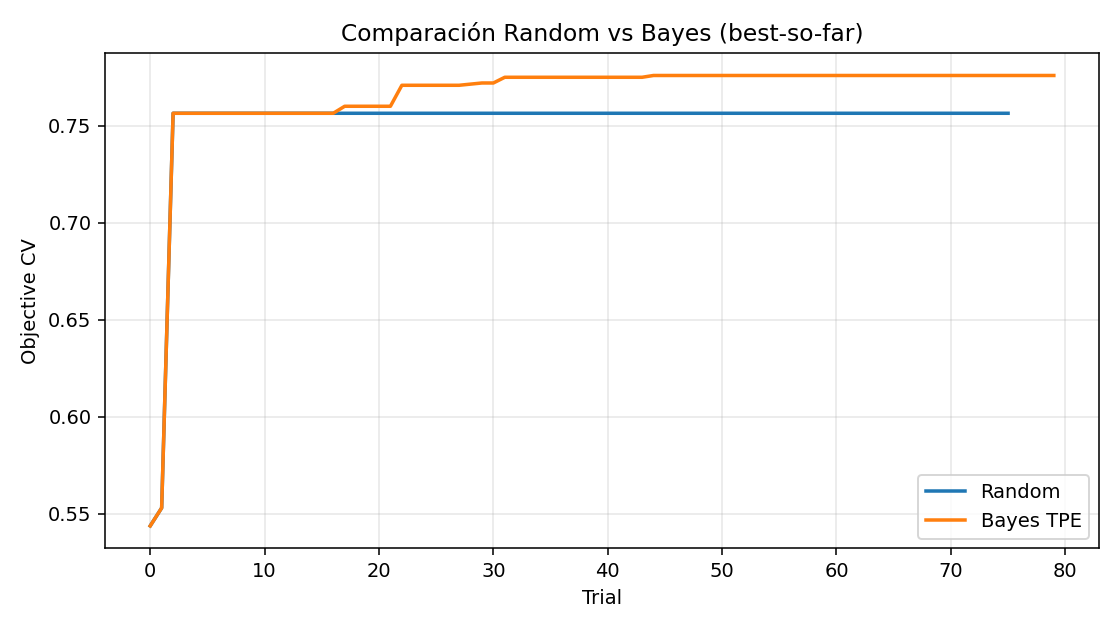

In [4]:

fig1 = OUT_DIR / 'figures' / 'evolution_best_so_far.png'
fig2 = OUT_DIR / 'figures' / 'comparison_random_vs_bayes.png'
for p in (fig1, fig2):
    display(Markdown(f'**{p.name}**'))
    display(Image(filename=str(p)))



## Resumen espacio, presupuesto y decisión


In [5]:

search_space = json.loads((OUT_DIR / 'search_space.json').read_text(encoding='utf-8'))
budget = json.loads((OUT_DIR / 'budget_summary.json').read_text(encoding='utf-8'))
winner = json.loads((OUT_DIR / 'winning_config.json').read_text(encoding='utf-8'))
sprint6_summary = json.loads((SPRINT6_DIR / 'summary.json').read_text(encoding='utf-8'))

print('=== Search space (resumen) ===')
for k, v in search_space['parameters'].items():
    print(f'  {k}: {v}')

print('\n=== Presupuesto ===')
for k, v in budget.items():
    print(f'  {k}: {v}')

print('\n=== Config ganadora ===')
print(json.dumps(winner, ensure_ascii=False, indent=2))

print('\n=== Conexión Sprint 6 ===')
print('Var2 baseline sprint6:', sprint6_summary['selected_var2_params'])
print('Modo calibración sprint6:', sprint6_summary['selected_calibration_mode'])



=== Search space (resumen) ===
  mode: {'type': 'categorical', 'choices': ['stop_heavy', 'balanced']}
  w_base: {'type': 'float', 'low': 0.15, 'high': 0.45}
  w_risk: {'type': 'float', 'low': 0.12, 'high': 0.38}
  w_p_stop: {'type': 'float', 'low': 0.08, 'high': 0.28}
  w_uncertainty: {'type': 'float', 'low': 0.05, 'high': 0.22}
  w_rag_gap: {'type': 'float', 'low': 0.02, 'high': 0.14}
  w_fuzzy_stop: {'type': 'float', 'low': 0.06, 'high': 0.22}
  threshold_stop: {'type': 'float', 'low': 0.48, 'high': 0.76, 'step': 0.02}
  threshold_pausa: {'type': 'float', 'low': 0.2, 'high': 0.56, 'step': 0.02}
  risk_stop_floor: {'type': 'float', 'low': 0.16, 'high': 0.48, 'step': 0.04}
  p_stop_floor: {'type': 'float', 'low': 0.36, 'high': 0.64, 'step': 0.04}
  stop_cost_threshold: {'type': 'float', 'low': 0.3, 'high': 0.54, 'step': 0.02}
  pause_uncertainty: {'type': 'float', 'low': 0.36, 'high': 0.58, 'step': 0.02}

=== Presupuesto ===
  n_trials_per_method: 80
  total_trials: 160
  cv_folds: 5
 

## Checklist entregable (slide del curso)

| Ítem | Estado | Evidencia |
|------|--------|-----------|
| 1. Experimentos comparables Random/Bayes con pruning | ✅ | `trials_random.csv`, `trials_bayes.csv`, MedianPruner + CV 5-fold |
| 2. Logs + artefactos guardados | ✅ | `logs/hpo_*.jsonl`, `search_space.json`, `budget_summary.json`, `winning_config.json` |
| 3. Tabla top-k y gráfico evolución | ✅ | `top_k_*.csv`, `figures/evolution_best_so_far.png` |
| 4. Resumen espacio/presupuesto/decisión | ✅ | Sección anterior + `winning_config.json` |

**Limitación explícita:** n=40 test + n=600 calibración → resultados piloto; el HPO mejora la política post-hoc, no sustituye un nuevo batch MetaGPT.
